In [1]:
import os

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
import graphviz
import pytorch_lightning as pl
import torchmetrics
import wandb

from torchview import draw_graph
from scipy.ndimage import gaussian_laplace
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor


%matplotlib inline

In [2]:
DEVICE = "cuda"

# Agenda

1. [Digital Image Representation](#Digital_Image_Representation)
2. [Mathematical Background](#Mathematical_Background)
3. [Convolution operation](#Convolution_operation)
4. [CNN building blocks](#CNN-building-blocks)
5. [Building CNN in Pytorch](#Building_CNN_in_Pytorch)
6. [CNN training pipeline](#Setting-up-CNN-training-pipeline)

# Resources
- [Chat with ChatGPT](https://chatgpt.com/share/68e263cd-d74c-8003-95ad-c1ef1de9b417)
- [Ostap Viniavskyi Lecture about Pytorch and CNNs](https://github.com/VSydorskyy/ucu_audio_processing_course/blob/main/Module_2/Lecture_2/Intro_to_Pytorch.ipynb)
- [Deep Learning by Ian Goodfellow and Yoshua Bengio and Aaron Courville. Chapter 9](https://www.deeplearningbook.org/contents/convnets.html)
- [Reddit: Why OpenCV reads the image with BGR and not in RGB?](https://www.reddit.com/r/opencv/comments/1jad9bm/discussion_why_opencv_reads_the_image_with_bgr/)
- [Inductive Bias In Machine Learning](https://medium.com/@sanjithkumar986/inductive-bias-in-machine-learning-f360ea678a15)
- [Inductive Bias In Deep Learning — 1](https://medium.com/@sanjithkumar986/inductive-bias-in-deep-learning-1-17a7c3f35381)

<a id='Digital_Image_Representation'></a>
# Digital Image Representation

A **digital image** is a discrete representation of a continuous visual scene, stored as a grid (matrix) of numerical values. Each value corresponds to a **pixel** — the smallest unit of the image — which holds information about **intensity** or **color**.  

Formally, an image can be described as a two-dimensional function:  

$$
f(x, y)
$$  

where $x$ and $y$ are spatial coordinates, and $f(x, y)$ gives the **intensity** (brightness or color value) at that point.  
In a digital system, both $x$ and $y$ are **discretized** (sampled) and $f(x, y)$ is **quantized** into integer values.  

---

## Grayscale Images  

A **grayscale image** contains a single intensity channel, where pixel values represent brightness from black to white.  
For an 8-bit image, pixel values range from **0 (black)** to **255 (white)**.  

| Bit Depth | Possible Values | Example |
|------------|----------------|----------|
| 1-bit | 0–1 | Black/White |
| 8-bit | 0–255 | Standard grayscale |
| 16-bit | 0–65,535 | High Dynamic Range (HDR) imaging |

Mathematically, a grayscale image of size $H \times W$ is represented as:  

$$
I =
\begin{bmatrix}
i_{11} & i_{12} & \dots & i_{1W} \\
i_{21} & i_{22} & \dots & i_{2W} \\
\vdots & \vdots & \ddots & \vdots \\
i_{H1} & i_{H2} & \dots & i_{HW}
\end{bmatrix}
$$  

Each element $i_{mn}$ represents the brightness intensity at pixel position $(m, n)$.

---

## Color Images and Channels  

A **color image** is formed by combining multiple channels — typically **Red (R)**, **Green (G)**, and **Blue (B)**.  
Each channel is a 2D matrix of intensities, and stacking them forms a 3D tensor:  

$$
I \in \mathbb{R}^{H \times W \times 3}
$$  

For example, a $224 \times 224$ RGB image is represented as a tensor of shape $(224, 224, 3)$.  
Each pixel’s final color is obtained by **additive mixing** of the three channels.  

---

## Color Spaces  

A **color space** defines how colors are numerically represented.  
Different color spaces emphasize various aspects of color perception or signal processing.  

| Color Space | Components | Description |
|--------------|-------------|--------------|
| **RGB** | Red, Green, Blue | Additive model used for displays and neural network inputs. |
| **HSV** | Hue, Saturation, Value | Separates color from brightness; useful for segmentation and filtering. |
| **LAB** | Lightness, A, B | Perceptually uniform; ideal for measuring color differences. |
| **YCbCr / YUV** | Luminance, Chrominance | Common in video compression; separates brightness from color. |

**Example: RGB → Grayscale Conversion**

Converting an RGB image to grayscale uses perceptual weighting:  

$$
Y = 0.299R + 0.587G + 0.114B
$$  

This formula reflects the human eye’s higher sensitivity to green and red light compared to blue.  

---

## Image Preprocessing  

Before feeding images into CNNs, **preprocessing** ensures uniformity and improves generalization. Common steps include:  

- **Resizing:** scale all images to a fixed input size (e.g., 224×224).  
- **Normalization:** adjust pixel values to a specific range (e.g., [0, 1] or z-score normalization).  
- **Augmentation:** apply random flips, rotations, or crops to increase dataset variability.  
- **Color Conversion:** transform to grayscale, HSV, or LAB if task-specific.  

These steps help **standardize inputs** and make neural networks more robust to illumination, orientation, and scale variations.  


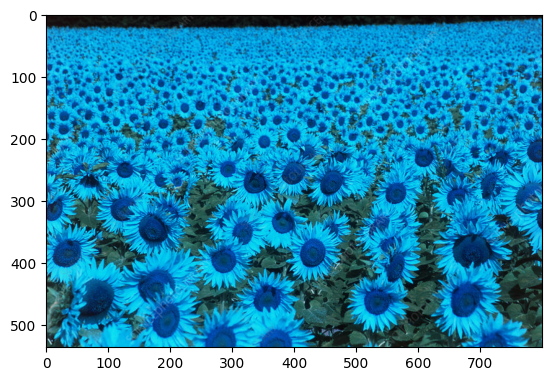

In [3]:
# Surprise surprise CV2 reads image in BGR
image = cv2.imread('images/sunplowers.jpeg')

plt.imshow(image)

In [4]:
print("Image Shape:", image.shape)

Image Shape: (536, 800, 3)


![](images/cv2_bgr.png)

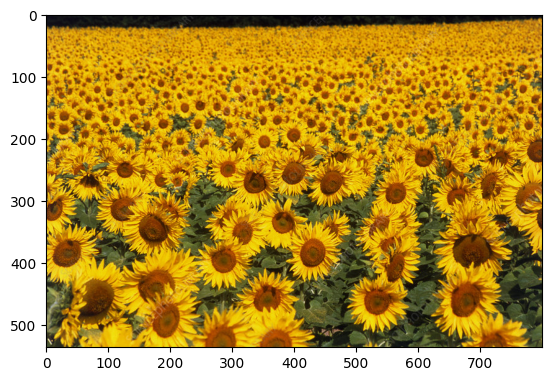

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)

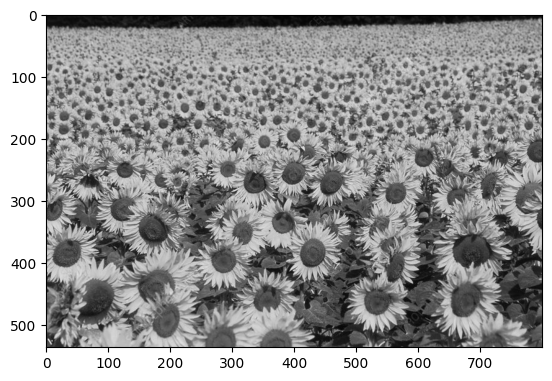

In [6]:
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

plt.imshow(image_gray, cmap='gray')

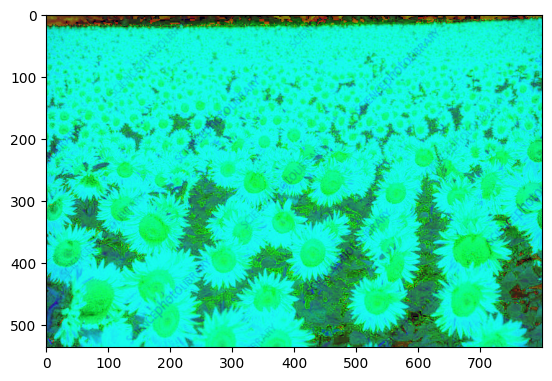

In [7]:
image_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

plt.imshow(image_hsv)

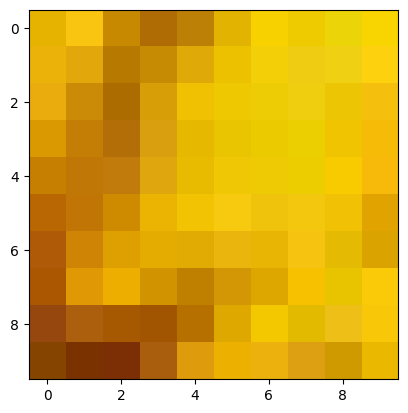

In [8]:
plt.imshow(image_rgb[200:210,200:210])

In [9]:
image[200:202,200:202]

array([[[  0, 179, 229],
        [ 17, 197, 249]],

       [[  9, 178, 235],
        [ 11, 167, 226]]], dtype=uint8)

In [10]:
image_rgb[200:202,200:202]

array([[[229, 179,   0],
        [249, 197,  17]],

       [[235, 178,   9],
        [226, 167,  11]]], dtype=uint8)

In [11]:
image_hsv[200:202,200:202]

array([[[ 23, 255, 229],
        [ 23, 238, 249]],

       [[ 22, 245, 235],
        [ 22, 243, 226]]], dtype=uint8)

In [12]:
image_gray[200:202,200:202]

array([[174, 192],
       [176, 167]], dtype=uint8)

<a id='Mathematical_Background'></a>
# Mathematical Background

in its most general form, **convolution** is an operation on two functions of a real-valued argument. It combines an **input function** and a **kernel (or filter)** to produce a **smoothed or transformed output**.  

To illustrate, imagine we are tracking the position of a spaceship using a noisy laser sensor. The sensor provides measurements $x(t)$ over time, and we wish to smooth these readings. This can be achieved by taking a **weighted average** of the recent measurements using a weighting function $w(a)$:  

$$
s(t) = \int x(a)\, w(t - a)\, da
$$  

This operation is called a **convolution**, and it is typically denoted by an asterisk $(*)$:  

$$
s(t) = (x * w)(t)
$$  

Here:  
- $x(t)$ — input signal (or image),  
- $w(t)$ — weighting function (kernel),  
- $s(t)$ — smoothed or filtered output.  

---

## Discrete Convolution  

In digital systems, signals and images are **discrete**.  
Thus, the convolution integral becomes summation:  

$$
s(t) = (x * w)(t) = \sum_{a=-\infty}^{\infty} x(a)\, w(t - a)
$$  

In practice, both $x$ and $w$ have finite size, and the summation runs only over the valid range of indices.  
This operation computes a **weighted sum** of neighboring values, where the weights are defined by the kernel $w$.  

---

## Two-Dimensional Convolution  

In image processing, convolution is extended to **two dimensions**.  
Let $I$ be a 2D input image and $K$ a 2D kernel.  
The discrete 2D convolution is defined as:  

$$
S(i, j) = (I * K)(i, j) = \sum_m \sum_n I(m, n)\, K(i - m, j - n)
$$  

This equation computes a **weighted average** of pixel intensities under the filter centered at position $(i, j)$.  
The output $S(i, j)$ forms a new image known as a **feature map**.

Convolution is **commutative**, meaning that:  

$$
S(i, j) = (K * I)(i, j) = \sum_m \sum_n I(i - m, j - n)\, K(m, n)
$$  

> **PROVE**: That Convolution is commutative

> **DERIVE**: How can we express a Fully Connected layer through Convolution and vice versa ?

---

## Convolutional Neural Networks (CNNs)  

A **Convolutional Neural Network (CNN)** is simply a neural network that uses **convolution operations** in place of general matrix multiplications in at least one of its layers.  

In traditional fully connected networks, each neuron is connected to all inputs.  
CNNs, on the other hand, use small convolutional kernels that slide across the input data, allowing them to:  
- **Share parameters** across spatial locations,  
- **Reduce the number of learnable parameters**,  
- **Capture local spatial patterns** such as edges, textures, and shapes.  

CNNs are particularly effective for **image, video, and spatial signal analysis**, where nearby pixels or features are highly correlated.


<a id='Convolution_operation'></a>
# Convolution operation

![](images/conv_filter.gif) <br>

In a 2D convolution operation, a small matrix called a **kernel** or **filter** slides over a larger input matrix (typically an image) to produce an output feature map. Mathematically, for an input $ X $ of size $ H \times W $ and a kernel $ K $ of size $ k_h \times k_w $, the convolution at position $ (i, j) $ is computed as:  

$$
Y(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} X(i+m, j+n) \cdot K(k_h - 1 - m, k_w - 1 - n)
$$

This operation captures **spatial patterns** by detecting local features such as edges, textures, and shapes. **Padding** can be applied to preserve spatial dimensions, while **strides** determine the step size of the kernel's movement. Multiple filters in a convolutional layer allow the extraction of diverse features, forming the foundation of deep learning architectures for image processing.

**EXAMPLE: 2D Laplacian of Gaussian (LoG)**  

The **Laplacian of Gaussian (LoG)** is a second-order edge detection operator that enhances regions of rapid intensity change. It is computed by first applying a **Gaussian blur** to smooth the image and then taking the **Laplacian**, which measures the second derivative of intensity. Mathematically, the **LoG filter** is defined as:

$$
\text{LoG}(x, y) = \nabla^2 (G(x, y) * I(x, y))
$$

where:
- $ G(x, y) $ is a Gaussian function that reduces noise,
- $ I(x, y) $ is the input image,
- $ \nabla^2 $ is the **Laplacian operator**, which detects regions of high curvature.

**Applications in Blob Detection**

LoG is widely used in **blob detection**, where blobs are defined as regions that differ significantly in intensity from their surroundings. The **zero-crossings** in the LoG output indicate blob-like structures, making it effective for tasks such as:
- **Keypoint detection** in image processing (e.g., in **SIFT** feature extraction).
- **Medical imaging**, where it highlights circular or irregular structures (e.g., cell or tumor detection).
- **Astronomy**, for identifying celestial objects like stars and galaxies.

(536, 800)


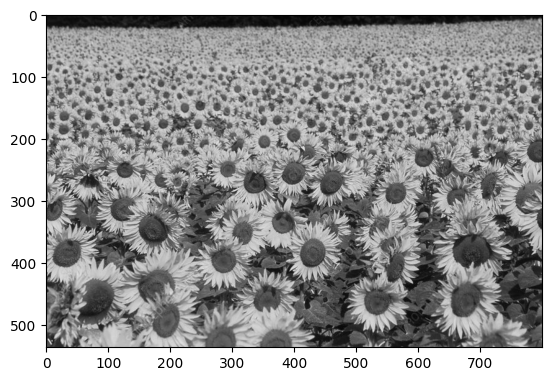

In [13]:
# Read image in grayscale
image = cv2.imread('images/sunplowers.jpeg', cv2.IMREAD_GRAYSCALE)
print(image.shape)

# Convert image to float32 and normalize to 0-1 range
image = image.astype(np.float32) / 255.
H, W = image.shape

plt.imshow(image, cmap='gray')

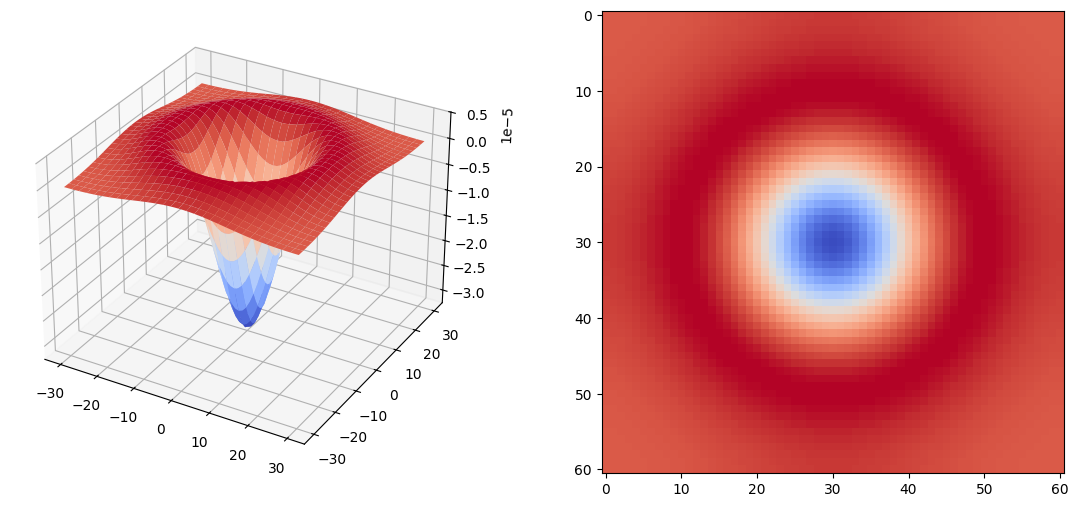

In [14]:
# Create Laplacian of Gaussian (LoG) kernel
def create_log_kernel(sigma):
    kernel_size = int(2 * np.ceil(3 * sigma) + 1)
    impulse_image = np.zeros((kernel_size, kernel_size))
    impulse_image[kernel_size // 2, kernel_size // 2] = 1  # Center pixel is 1

    return gaussian_laplace(impulse_image, sigma=sigma)


def visualize_log_kernel(log_kernel):
    kernel_size = log_kernel.shape[0]
    ax = np.linspace(-(kernel_size // 2), kernel_size // 2, kernel_size)
    xx, yy = np.meshgrid(ax, ax)
    
    fig = plt.figure(figsize=(14, 6))
    
    ax = fig.add_subplot(121, projection='3d')
    ax.plot_surface(xx, yy, log_kernel, cmap='coolwarm')
    
    ax = fig.add_subplot(122)
    ax.imshow(log_kernel, cmap='coolwarm')
    
    plt.show()

log_kernel_s5 = create_log_kernel(sigma=5).astype(np.float32)
log_kernel_s10 = create_log_kernel(sigma=10).astype(np.float32)
visualize_log_kernel(log_kernel_s10)

## Concept of Impulse Image (from Control Theory Perspective)  

In **Control Theory** and **Signal Processing**, the **impulse function** — denoted as $\delta(t)$ in continuous systems or $\delta[n]$ in discrete systems — is a fundamental concept used to describe system responses.  

- The **impulse** represents a signal that is zero everywhere except at one point, where it has unit magnitude:  
  $$
  \delta[n] =
  \begin{cases}
    1, & n = 0 \\
    0, & n \neq 0
  \end{cases}
  $$  

- The **impulse response** of a system characterizes how the system reacts to this idealized input.  
  Once we know the impulse response $h(t)$ (or $h[n]$), we can determine the output to any arbitrary input $x(t)$ by **convolution**:  
  $$
  y(t) = x(t) * h(t)
  $$  

In the context of **image processing**, an **impulse image** is the 2D analog of the Dirac delta function.  
It is a matrix of zeros with a single central pixel set to 1:  

$$
\delta(x, y) =
\begin{cases}
1, & (x, y) = (0, 0) \\
0, & \text{otherwise}
\end{cases}
$$  

When we apply a filter (such as Gaussian blur, Sobel, or Laplacian) to an impulse image, the result is the **spatial kernel representation** of that filter — essentially its **impulse response**.  

This is why, in the LoG example, applying the `gaussian_laplace()` function to an impulse image directly yields the **LoG kernel** itself.  


In [15]:
%%time

def convolve_gray(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Perform convolution on a grayscale image using the given kernel.

    :param image: 2D NumPy array representing the grayscale image
    :param kernel: 2D NumPy array representing the convolution filter
    :return: 2D NumPy array of the convolved image
    """
    # Get dimensions
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape
    
    # Compute padding size
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2
    
    # Pad the image with zeros
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Output image
    output = np.zeros((img_h, img_w), dtype=np.float32)
    
    # Flip the kernel for convolution
    kernel = np.flipud(np.fliplr(kernel))
    
    # Perform convolution
    for i in range(img_h):
        for j in range(img_w):
            patch = padded_image[i:i+kernel_h, j:j+kernel_w]
            output[i, j] = np.sum(patch * kernel)
    
    return output

log5_image = convolve_gray(image, log_kernel_s5)
log10_image = convolve_gray(image, log_kernel_s10)

CPU times: user 7.83 s, sys: 0 ns, total: 7.83 s
Wall time: 7.85 s


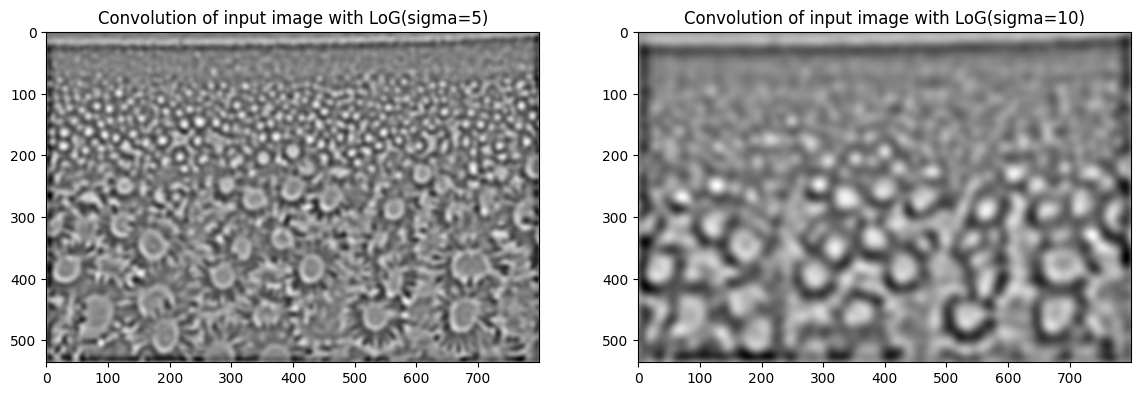

In [16]:
fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(121,)
ax.imshow(log5_image, cmap='gray')
ax.title.set_text("Convolution of input image with LoG(sigma=5)")

ax = fig.add_subplot(122)
ax.imshow(log10_image, cmap='gray')
ax.title.set_text("Convolution of input image with LoG(sigma=10)")

plt.show()

> **EXPLORE**: [3Blue1Brown video - Intuitive explanation of convolution operation](https://www.youtube.com/watch?v=KuXjwB4LzSA&ab_channel=3Blue1Brown); [Stanford Noted - Great convolution output size explanation and other CNN-related stuff](https://cs231n.github.io/convolutional-networks/); [Medium article - Efficient convolution implementation strategies](https://medium.com/@sundarramanp2000/different-implementations-of-the-ubiquitous-convolution-6a9269dbe77f)

<a id='CNN-building-blocks'></a>
# CNN building blocks

**Multichannel Convolution**

In deep learning, **multichannel convolution** extends the standard 2D convolution operation to handle inputs with multiple channels, such as RGB images or feature maps in deeper layers of a neural network. Unlike single-channel convolution, where a **2D kernel** slides over a single input, in multichannel convolution, a separate kernel is applied to **each input channel**, and the results are summed to produce a **single output value** per spatial location.  

For an input tensor of size $H \times W \times C_{\text{in}}$ (height, width, and number of channels), a convolutional layer with $C_{\text{out}}$ filters applies a **kernel of size** $k_h \times k_w \times C_{\text{in}}$ per filter. Each filter produces a single output channel, resulting in an output tensor of size $H' \times W' \times C_{\text{out}}$, where $H'$ and $W'$ depend on padding and stride.  

*Example*:  
- **Input:** $32 \times 32 \times 3$ (RGB image)  
- **Kernel:** $3 \times 3 \times 3$  
- **Output (with 16 filters):** $30 \times 30 \times 16$ (if no padding, stride = 1)  

In deeper layers, multichannel convolution enables networks to learn complex hierarchical features by combining multiple filters. This is essential for tasks like **image classification, object detection, and segmentation**.

**MaxPooling 2D (MaxPool2D)** 

**MaxPooling 2D** (MaxPool2D) is a downsampling operation commonly used in convolutional neural networks (CNNs) to reduce spatial dimensions while retaining important features. It operates by sliding a **fixed-size window** (e.g., $2 \times 2$ or $3 \times 3$) over the input feature map and selecting the **maximum value** within each window. This process helps to reduce computation, increase translation invariance, and improve robustness to small spatial variations.  

For an input feature map of size $H \times W \times C$, applying a max-pooling operation with a window of size $k_h \times k_w$ and stride $s$ results in an output feature map of size:

$$
H' = \frac{H - k_h}{s} + 1, \quad W' = \frac{W - k_w}{s} + 1
$$

*Example*:
- **Input:** $32 \times 32 \times 64$ feature map  
- **MaxPool:** $2 \times 2$ window, stride = 2  
- **Output:** $16 \times 16 \times 64$  

Unlike convolution, max-pooling does not have learnable parameters—it simply selects the strongest activations. This makes it an effective tool for reducing spatial size while preserving dominant features, helping CNNs generalize better for tasks like **image classification and object detection**.

**Average pooling 2d (AvgPool2d)**

**Average pooling 2d** computes the mean of pixel values in a small local region (e.g., $2\times2$ or $3\times3$ window) and outputs a single representative value.  
Mathematically, it can be seen as a convolution with a uniform kernel:  

$$
K_{avg}(m, n) = \frac{1}{k_h \times k_w}
$$  

The output of average pooling is then:  

$$
S(i, j) = \frac{1}{k_h \times k_w} \sum_m \sum_n I(i+m, j+n)
$$  

**Batch Normalization (BatchNorm2d)**  

**Batch Normalization 2d** covered in Module 1 Lecture 4


In [17]:
# Convert image and kernel to torch
image_t_cpu = torch.tensor(image, dtype=torch.float32, device="cpu")
log_kernel_s5_t_cpu = torch.tensor(log_kernel_s5, dtype=torch.float32, device="cpu")
log_kernel_s10_t_cpu = torch.tensor(log_kernel_s10, dtype=torch.float32, device="cpu")

# unsqueeze dimensions in the tensor
# image [H, W] -> [B=1, C=1, H, W]
image_t_cpu = image_t_cpu.unsqueeze(0).unsqueeze(0)
print(f"{image_t_cpu.shape=}")

# kernel [KH, KW] -> [N=1, M=1, KH, KW]
log_kernel_s5_t_cpu = log_kernel_s5_t_cpu.unsqueeze(0).unsqueeze(0)
print(f"{log_kernel_s5_t_cpu.shape=}")

log_kernel_s10_t_cpu = log_kernel_s10_t_cpu.unsqueeze(0).unsqueeze(0)
print(f"{log_kernel_s10_t_cpu.shape=}")

# create GPU version of tensors
image_t_device = image_t_cpu.to(DEVICE)
log_kernel_s5_t_device = log_kernel_s5_t_cpu.to(DEVICE)
log_kernel_s10_t_device = log_kernel_s10_t_cpu.to(DEVICE)

image_t_cpu.shape=torch.Size([1, 1, 536, 800])
log_kernel_s5_t_cpu.shape=torch.Size([1, 1, 31, 31])
log_kernel_s10_t_cpu.shape=torch.Size([1, 1, 61, 61])


In [18]:
%%time
log5_image_t_cpu = F.conv2d(image_t_cpu, log_kernel_s5_t_cpu, padding=log_kernel_s5_t_device.shape[-1]//2)
log10_image_t_cpu = F.conv2d(image_t_cpu, log_kernel_s10_t_cpu, padding=log_kernel_s10_t_device.shape[-1]//2)

CPU times: user 34.7 s, sys: 5.82 ms, total: 34.7 s
Wall time: 4.53 s


In [19]:
%%time
log5_image_t_device = F.conv2d(image_t_device, log_kernel_s5_t_device, padding=log_kernel_s5_t_device.shape[-1]//2)
log10_image_t_device = F.conv2d(image_t_device, log_kernel_s10_t_device, padding=log_kernel_s10_t_device.shape[-1]//2)
torch.cuda.synchronize(0)

CPU times: user 78.5 ms, sys: 52.9 ms, total: 131 ms
Wall time: 249 ms


log5_image_t_device.shape=torch.Size([1, 1, 536, 800])
log10_image_t_device.shape=torch.Size([1, 1, 536, 800])


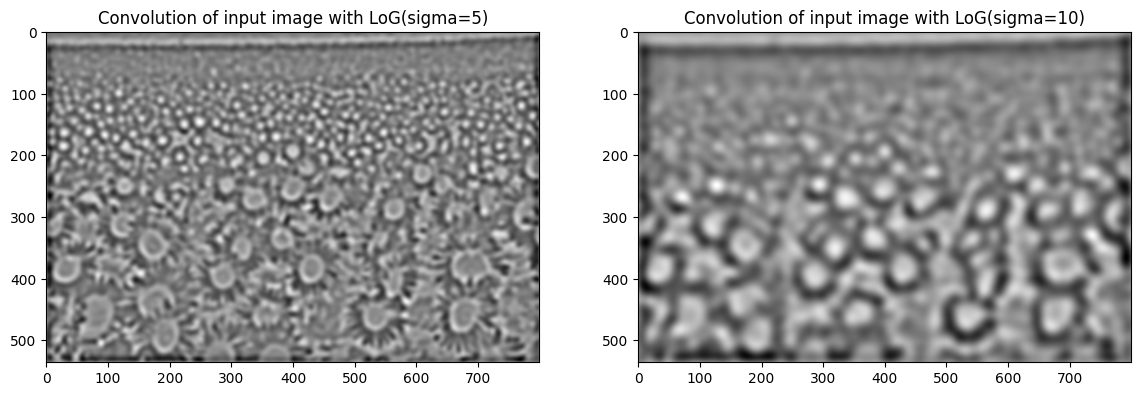

In [20]:
print(f"{log5_image_t_device.shape=}")
print(f"{log10_image_t_device.shape=}")

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(121)
ax.imshow(log5_image_t_device.cpu()[0, 0], cmap='gray')
ax.title.set_text("Convolution of input image with LoG(sigma=5)")

ax = fig.add_subplot(122)
ax.imshow(log10_image_t_device.cpu()[0, 0], cmap='gray')
ax.title.set_text("Convolution of input image with LoG(sigma=10)")

plt.show()

max_pool_out.shape=torch.Size([1, 1, 67, 100])


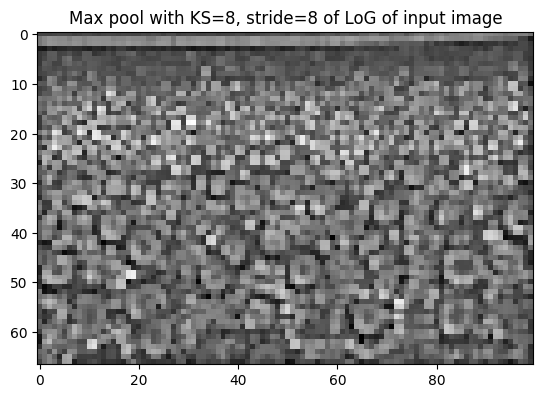

In [21]:
max_pool_out = F.max_pool2d(log5_image_t_device, kernel_size=8, stride=8, )

print(f"{max_pool_out.shape=}")
plt.imshow(max_pool_out.cpu()[0, 0], cmap='gray')
plt.title("Max pool with KS=8, stride=8 of LoG of input image")
plt.show()

<a id='Building_CNN_in_Pytorch'></a>
# Building CNN in Pytorch

## What CNNs Learn Internally

![](images/feat_by_layers.webp) <br>

In a Convolutional Neural Network (CNN), the filters in different layers learn to detect features of increasing complexity. In the **early layers**, filters typically learn to detect **low-level patterns** such as edges, textures, and simple shapes. As the network goes deeper, these filters begin to recognize **mid-level patterns** like corners, contours, and more complex textures. In the **final layers**, the network learns **high-level semantic features**, such as object parts or entire objects, which are crucial for classification and detection tasks.  

## Concept of Receptive Field

A key concept in CNNs is the **receptive field**, which refers to the region of the input image that influences a particular neuron in a feature map. In the **earlier layers**, the receptive field is small, meaning each neuron captures only local patterns. As we move deeper into the network, stacking convolution and pooling layers increases the **effective receptive field**, allowing neurons to capture larger spatial relationships. This hierarchical feature extraction enables CNNs to recognize objects at different scales and positions, making them highly effective for visual tasks. 

### Mathematical Definition  

The receptive field size at layer $l$, denoted as $R_l$, can be computed recursively using the following formula:  

$$
R_l = R_{l-1} + (k_l - 1) \times j_{l-1}
$$

where:  
- $R_l$ — receptive field size at layer $l$,  
- $k_l$ — kernel (filter) size of layer $l$,  
- $j_{l-1}$ — total **jump** (stride accumulation) from previous layer, defined recursively as  
  $$
  j_l = j_{l-1} \times s_l
  $$  
  with $s_l$ being the stride of layer $l$.  

Initialization:  
$$
R_0 = 1, \quad j_0 = 1
$$  

This means each new convolution layer increases the receptive field depending on the **kernel size** and **stride** of all previous layers.

### Example: 3-Layer CNN  

Suppose we have a simple CNN with:  
1. **Conv1:** kernel size = 3, stride = 1  
2. **Conv2:** kernel size = 3, stride = 2  
3. **Conv3:** kernel size = 3, stride = 1  

We can compute the receptive field step-by-step:

| Layer | Kernel $k$ | Stride $s$ | Jump $j$ | Receptive Field $R$ |
|--------|-------------|-------------|-----------|---------------------|
| Input | — | — | 1 | 1 |
| Conv1 | 3 | 1 | $1 \times 1 = 1$ | $1 + (3 - 1)\times 1 = 3$ |
| Conv2 | 3 | 2 | $1 \times 2 = 2$ | $3 + (3 - 1)\times 1 = 5$ |
| Conv3 | 3 | 1 | $2 \times 1 = 2$ | $5 + (3 - 1)\times 2 = 9$ |

So the **final receptive field** after the third convolution layer is:

$$
R_3 = 9
$$

That means each neuron in the third layer's feature map corresponds to a **9×9 region** in the original input image.


## Translation Equivariance in Convolution

![](images/equivariance.webp) <br>

One of the fundamental properties of convolution is **translation equivariance**. This means that if an object in the input image shifts spatially, the output feature map shifts accordingly but remains otherwise unchanged. Mathematically, if $f(X)$ represents a convolution operation on an input image $X$, and $T$ is a translation operator, then:

$$
f(T(X)) = T(f(X))
$$



## Inductive Bias in Machine Learning and CNNs  

![](images/inductive_bias.webp) <be>
    
*Taken from [Inductive Bias In Machine Learning](https://medium.com/@sanjithkumar986/inductive-bias-in-machine-learning-f360ea678a15)*

In **Machine Learning**, an **inductive bias** refers to the set of assumptions a learning algorithm makes in order to generalize from limited training data to unseen examples.  

Formally, inductive bias defines **how the model searches** for a function $f$ that maps inputs $x$ to outputs $y$ given only a finite set of samples $(x_i, y_i)$.  

Without such bias, the model could perfectly memorize the training data but fail to generalize.  

---

### The Role of Inductive Bias in Generalization  

As one can see from previous examples, **choosing the right inductive bias** is essential for achieving good generalization, especially in a **low-data regime**.  

- When **training data is scarce**, we rely more on **strong inductive biases** (e.g., structural constraints, priors, symmetry assumptions) to help the model infer meaningful patterns.  
- When **lots of data** is available, it may be preferable to use **weaker or minimal biases**, allowing the model to explore the hypothesis space more freely and learn directly from data.  

In other words:  
> **The less data we have, the stronger the inductive bias should be.**  
> **The more data we have, the weaker the inductive bias can be.**

---

### CNN Inductive Bias  

Convolutional Neural Networks (CNNs) incorporate several strong **inductive biases** that reflect assumptions about the structure of visual data and help them generalize effectively:

- **Translation Invariance:** CNNs can recognize patterns regardless of their position in the image. This is achieved through convolutional layers that apply the same filters across spatial locations.  
- **Local Receptive Fields:** Each kernel processes only a small neighborhood of pixels, based on the assumption that local spatial patterns (like edges or corners) are meaningful.  
- **Hierarchical Feature Learning:** CNNs learn a hierarchy of representations — early layers capture low-level details, while deeper layers encode complex structures and object semantics.  
- **Pooling Layers:** Pooling reduces spatial dimensions and focuses on the most salient features, introducing invariance to small shifts or distortions.  
- **Weight Sharing:** The same filter weights are reused across the input, drastically reducing parameters and enforcing the idea that similar features can appear anywhere in the image.  
- **Spatial Hierarchies:** Stacking layers allows CNNs to build spatial hierarchies, where high-level features are composed of combinations of lower-level ones.  
- **Parameter Sharing:** Reusing parameters across regions improves computational efficiency and regularization, minimizing overfitting while maintaining expressive power.  

These inductive biases collectively constrain CNNs toward learning **translation-invariant**, **hierarchical**, and **spatially aware** representations — perfectly aligned with the natural structure of visual data.


## AlexNet

**AlexNet**, introduced by **Krizhevsky et al. (2012)**, was a groundbreaking deep learning model that won the **ImageNet Large Scale Visual Recognition Challenge (ILSVRC-2012)** with a **top-5 error rate of 15.3%**, significantly outperforming traditional computer vision methods. It was one of the first deep **Convolutional Neural Networks (CNNs)** to demonstrate the power of deep learning in large-scale image classification.  

AlexNet consists of **eight layers**: five **convolutional layers** followed by three **fully connected layers**. The architecture employs **ReLU activations** instead of traditional sigmoid/tanh functions, enabling faster training. It also introduces **dropout** in the fully connected layers to reduce overfitting. To efficiently train on large datasets, AlexNet used **GPU acceleration** with two parallel NVIDIA GTX 580 GPUs. Additionally, **overlapping max-pooling** was used to enhance translation invariance, and **data augmentation** (such as random cropping and flipping) was applied to improve generalization.  

AlexNet's success marked the beginning of the **deep learning revolution**, inspiring later architectures such as **VGG, ResNet, and DenseNet**. Despite being relatively simple by modern standards, it remains a foundational model in computer vision.

![](images/alexnet.png) <br>


In [22]:
# Define CIFAR-10 class names
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

class AlexNet(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False):
        super(AlexNet, self).__init__()
        self.use_batchnorm = use_batchnorm

        # --- Convolutional layers ---
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0)
        self.bn1 = nn.BatchNorm2d(96) if use_batchnorm else nn.Identity()
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(256) if use_batchnorm else nn.Identity()
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(384) if use_batchnorm else nn.Identity()

        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(384) if use_batchnorm else nn.Identity()

        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256) if use_batchnorm else nn.Identity()
        self.pool5 = nn.MaxPool2d(kernel_size=3, stride=2)

        # --- Activation and Dropout ---
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=0.6)

        # --- Fully connected layers ---
        self.fc1 = nn.Linear(256 * 6 * 6, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, num_classes)

    def forward(self, x):
        # Convolutional feature extraction
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool5(self.relu(self.bn5(self.conv5(x))))

        # Flatten features
        x = torch.flatten(x, 1)

        # Fully connected classification head
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x


# Example usage
model = AlexNet(num_classes=len(CLASSES))
print(model)

AlexNet(
  (conv1): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (bn1): Identity()
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): Identity()
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): Identity()
  (conv4): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): Identity()
  (conv5): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): Identity()
  (pool5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc1): Linear(in_features=9216, out_features=4096, bias=True)
  (fc2): Linear(in_features=4096, out_features=4096, bias=True)
  (fc3): Linear(in_features=4096, out_features=10, bias=

num_model_params=58322314


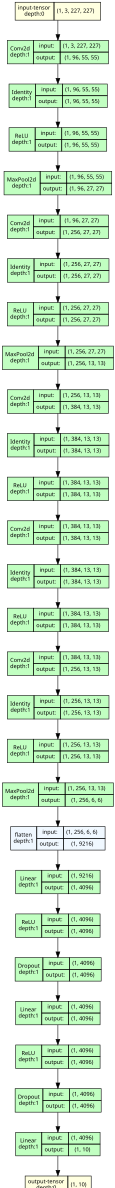

In [23]:
num_model_params = sum(p.numel() for p in model.parameters())
print(f"{num_model_params=}")

model_graph = draw_graph(model, input_size=(1, 3, 227, 227), expand_nested=True, device="meta")
model_graph.visual_graph

<a id='Setting-up-CNN-training-pipeline'></a>
# CNN training pipeline

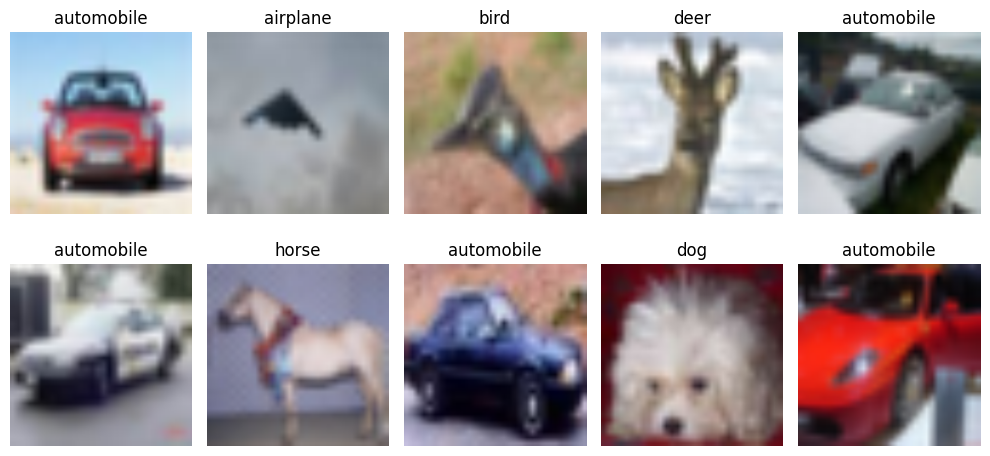

In [24]:
# Load CIFAR-10 dataset
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(227),  # Resize for AlexNet
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Get a batch of training data
data_iter = iter(trainloader)
images, labels = next(data_iter)

# Denormalize images for correct visualization
def denormalize(img):
    img = img * 0.5 + 0.5  # Reverse normalization
    return img.clamp(0, 1)  # Ensure values are in valid range

# Plot images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # 2 rows, 5 columns
axes = axes.flatten()

for i in range(10):
    img = denormalize(images[i]) 
    img = img.permute(1, 2, 0)
    
    axes[i].imshow(img)
    axes[i].set_title(CLASSES[labels[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [25]:
class LitCNN(pl.LightningModule):
    def __init__(
        self, 
        initial_lr=1e-3, 
        final_lr=1e-5, 
        T_max=10,
        use_batchnorm=False
    ):
        super().__init__()
        self.save_hyperparameters()
        self.model = AlexNet(use_batchnorm=self.hparams.use_batchnorm, num_classes=len(CLASSES))
        self.criterion = nn.CrossEntropyLoss()
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=len(CLASSES))
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=len(CLASSES))

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        self.train_acc.update(preds, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        acc = self.train_acc.compute()
        self.log("train_acc", acc, prog_bar=True)
        self.train_acc.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        self.val_acc.update(preds, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        acc = self.val_acc.compute()
        self.log("val_acc", acc, prog_bar=True)
        self.val_acc.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.initial_lr
        )
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, 
                T_max=self.hparams.T_max,
                eta_min=self.hparams.final_lr
            ),
            "interval": "step"
        }
        return (
            [optimizer],
            [scheduler]
        )

class CIFAR10DataModule(pl.LightningDataModule):
    def __init__(self, data_root="../../data", batch_size=64, num_workers=None):
        super().__init__()
        self.data_root = data_root
        self.batch_size = batch_size
        self.num_workers = num_workers or max(os.cpu_count()-1, 1)

    def setup(self, stage=None):
        # Load CIFAR-10 dataset
        transform = torchvision.transforms.Compose([
            torchvision.transforms.Resize(227),  # Resize for AlexNet
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        self.train_ds = torchvision.datasets.CIFAR10(root=self.data_root, train=True, download=True, transform=transform)
        self.val_ds   = torchvision.datasets.CIFAR10(root=self.data_root, train=False, download=True, transform=transform)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            self.train_ds, batch_size=self.batch_size, 
            shuffle=True, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return torch.utils.data.DataLoader(
            self.val_ds, batch_size=self.batch_size, 
            shuffle=False, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

N_EPOCHS = 10
datamodule = CIFAR10DataModule(num_workers=4, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
    use_batchnorm=False
)

In [26]:
# Set your W&B token
os.environ["WANDB_API_KEY"]="???"

In [27]:
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_alexnet_baseline"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_alexnet_baseline-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: sydorskyiv (sydorskyiv-igor-sikorsky-kyiv-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | AlexNet            | 58.3 M | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
58.3 M    Trainable params
0         Non-trainable params
58.3 M    Total params
233.289   Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
lr-Adam,████████▇▇▇▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train_acc,▁▃▄▄▅▆▆▇██
train_loss_epoch,█▆▆▅▄▃▃▂▁▁
train_loss_step,██▇▆▆▄▆▅▅▅▅▄▃▅▄▅▄▅▃▄▃▃▃▃▃▃▂▂▂▂▃▂▁▂▂▂▂▂▁▂
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇██
val_acc,▁▃▅▆▇▇████
val_loss,█▆▄▃▂▁▁▁▁▂
epoch,9
lr-Adam,1e-05
train_acc,0.842


In [29]:
datamodule = CIFAR10DataModule(num_workers=4, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
    use_batchnorm=True
)
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_alexnet_withBN"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_alexnet_withBN-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | AlexNet            | 58.3 M | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
58.3 M    Trainable params
0         Non-trainable params
58.3 M    Total params
233.300   Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇█████
lr-Adam,███████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
train_acc,▁▂▂▄▆▆▇███
train_loss_epoch,█▆▆▅▃▃▂▂▁▁
train_loss_step,██▇█▇▇▆▇▇▆▅▇▆▅▅▅▅▄▄▃▂▄▄▃▃▃▂▂▂▂▃▂▃▁▁▂▂▂▁▁
trainer/global_step,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇███
val_acc,▁▂▄▅▆▇▇███
val_loss,█▇▆▄▃▂▂▁▁▁
epoch,9
lr-Adam,1e-05
train_acc,0.7806


## Inference of CNN model

In [37]:
alexnet_baseline = AlexNet(num_classes=len(CLASSES))
alexnet_baseline.load_state_dict({
    k.replace("model.", ""):v for k, v in torch.load(
        "kse_deep_learning_course/5uq5o6h5/checkpoints/cifar10_alexnet_baseline-epoch=09-val_acc=0.6805.ckpt",
        map_location="cpu"
    )["state_dict"].items()
})
alexnet_baseline.to(DEVICE)
alexnet_baseline.eval();

In [38]:
alexnet_bn = AlexNet(num_classes=len(CLASSES), use_batchnorm=True)
alexnet_bn.load_state_dict({
    k.replace("model.", ""):v for k, v in torch.load(
        "kse_deep_learning_course/m9k377he/checkpoints/cifar10_alexnet_withBN-epoch=08-val_acc=0.7716.ckpt",
        map_location="cpu"
    )["state_dict"].items()
})
alexnet_bn.to(DEVICE)
alexnet_bn.eval();

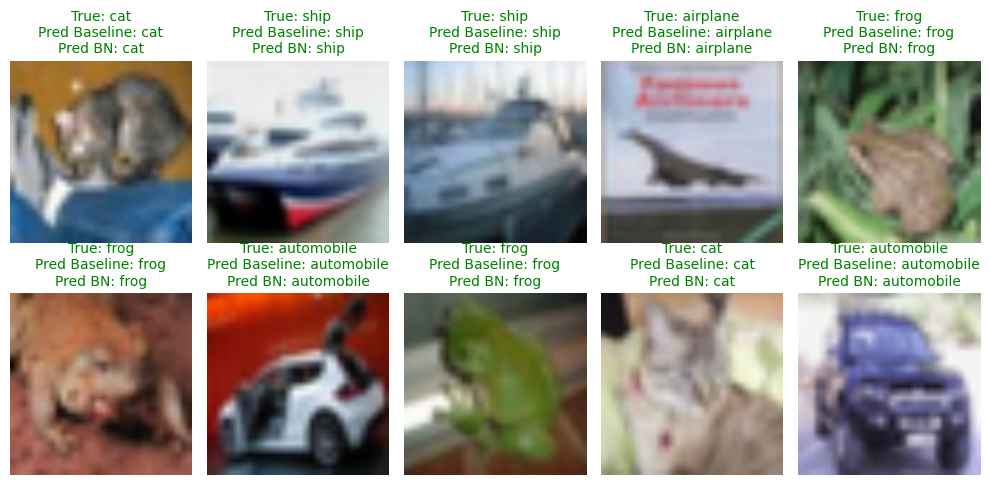

In [41]:
# Get a batch of test data
data_iter = iter(testloader)
images, labels = next(data_iter)

# Move images to the same device as the model
images = images.to(DEVICE)

# Make predictions
model.eval()  
with torch.no_grad():
    _, predicted_baseline = torch.max(alexnet_baseline(images), 1)
    _, predicted_bn = torch.max(alexnet_bn(images), 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # 2 rows, 5 columns
axes = axes.flatten()

for i in range(10):
    img = denormalize(images[i].cpu()) 
    img = img.permute(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)

    true_label = CLASSES[labels[i].item()]
    pred_label_baseline = CLASSES[predicted_baseline[i].item()]
    pred_label_bn = CLASSES[predicted_bn[i].item()]
    
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true_label}\nPred Baseline: {pred_label_baseline}\nPred BN: {pred_label_bn}", 
        fontsize=10,
        color="green" if true_label == pred_label_baseline else "red"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()


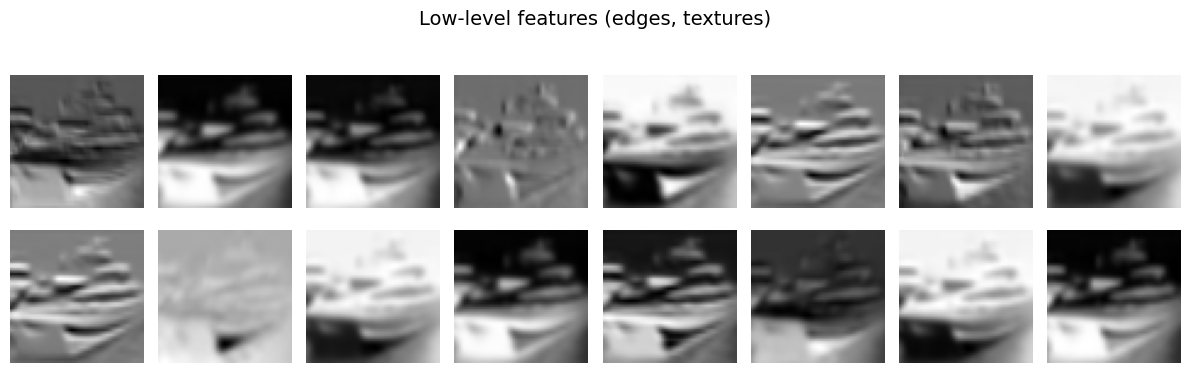

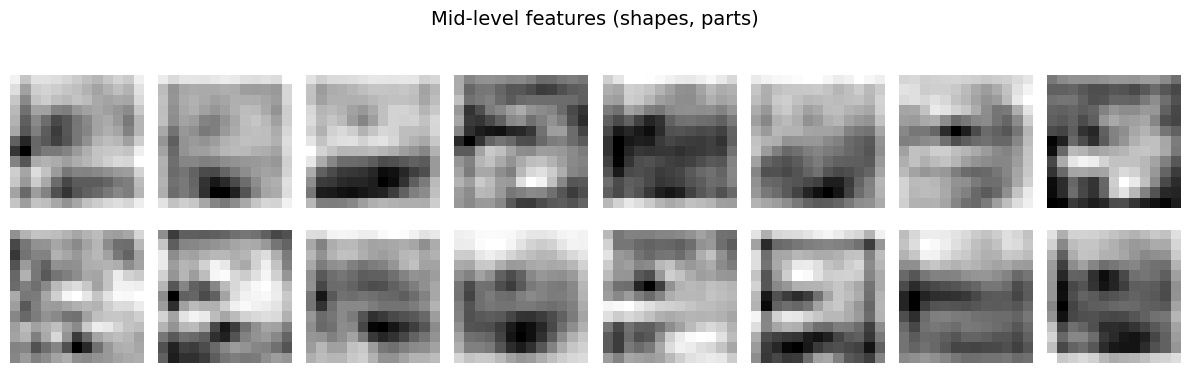

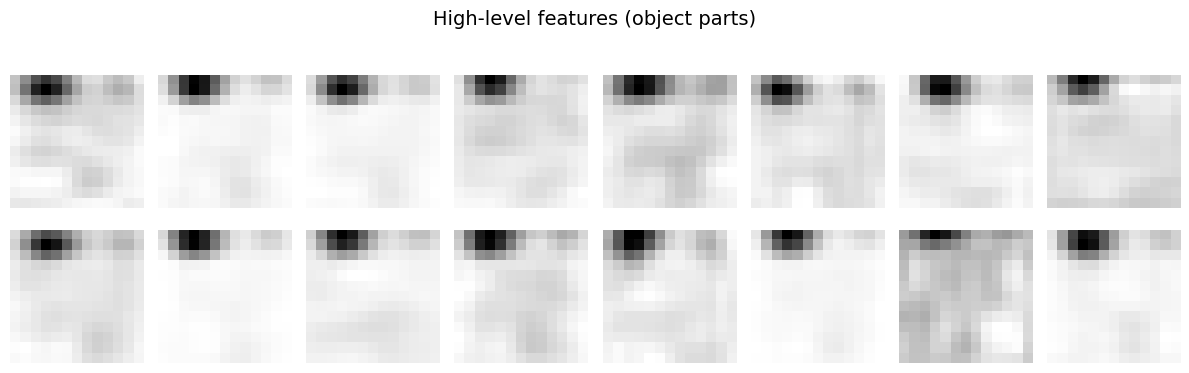

In [43]:
# -----------------------------
# 1. Hook to capture activations
# -----------------------------
activation_maps = {}

def get_activation(name):
    def hook(model, input, output):
        activation_maps[name] = output.detach().cpu()
    return hook

# Register hooks for convolutional layers
alexnet_bn.conv1.register_forward_hook(get_activation("conv1"))
alexnet_bn.conv2.register_forward_hook(get_activation("conv2"))
alexnet_bn.conv3.register_forward_hook(get_activation("conv3"))
alexnet_bn.conv4.register_forward_hook(get_activation("conv4"))
alexnet_bn.conv5.register_forward_hook(get_activation("conv5"))

# -----------------------------
# 2. Forward pass on one image
# -----------------------------
with torch.no_grad():
    sample_img = images[1].unsqueeze(0)  # one image
    _ = alexnet_bn(sample_img)

# -----------------------------
# 3. Visualize selected activations
# -----------------------------
def visualize_feature_maps(activation, title, num_features=16):
    """
    Display a grid of feature maps for one layer.
    """
    act = activation.squeeze(0)  # shape: (C, H, W)
    num_features = min(num_features, act.size(0))
    fig, axes = plt.subplots(2, num_features // 2, figsize=(12, 4))
    axes = axes.flatten()

    for i in range(num_features):
        axes[i].imshow(act[i], cmap='gray')
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4. Example: visualize progression
# -----------------------------
visualize_feature_maps(activation_maps["conv1"], "Low-level features (edges, textures)")
visualize_feature_maps(activation_maps["conv3"], "Mid-level features (shapes, parts)")
visualize_feature_maps(activation_maps["conv5"], "High-level features (object parts)")


**How to improve the model**: 
- investigtate if the model overfits - prevent overfitting by regularization
- pretrained model initialization - explore [Transfer Learning](https://towardsdatascience.com/transfer-learning-for-beginner-9b59490d1b9d/)
- add [augmentations](https://towardsdatascience.com/complete-guide-to-data-augmentation-for-computer-vision-1abe4063ad07/)
- explore other architectures - [ResNet](https://towardsdatascience.com/resnets-why-do-they-perform-better-than-classic-convnets-conceptual-analysis-6a9c82e06e53/), [MobileNet](https://medium.com/towards-data-science/understanding-depthwise-separable-convolutions-and-the-efficiency-of-mobilenets-6de3d6b62503), [ShuffleNet](https://medium.com/towards-data-science/review-shufflenet-v1-light-weight-model-image-classification-5b253dfe982f)
